In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
qpcr_df = pd.read_csv('/Users/timothy/Documents/EV-Res-Local/qPCR_UMUC1-HT8.csv')
rnaseq_df = pd.read_csv('/Users/timothy/Documents/EV-Res-Local/UP_vs_UR.csv')

qpcr_df

,Sample Name,Target Name,CT,Ct Mean,HIGHSD,NOAMP,EXPFAIL
0,UMUC1,ACTIN,18.327,18.252,N,N,N
1,UMUC1,ACTIN,18.177,18.252,N,N,N
2,UMUC1,EHD3,27.914,27.930,N,N,N
3,UMUC1,EHD3,27.945,27.930,N,N,N
4,UMUC1,CLIC4,24.1,24.090,N,N,N
...,...,...,...,...,...,...,...
175,UMUC1,SAT1,23.286,23.297,N,N,N
176,HT8,FAP,Undetermined,36.632,N,Y,Y
177,HT8,FAP,36.632,36.632,N,N,N
178,HT8,SAT1,22.762,22.735,N,N,N


In [29]:
def calculate_ddct(df, goi, hkg, reference_sample, test_sample):
    """
    Calculate 2^-ΔΔCt for qPCR data.

    Parameters:
        df               : DataFrame with columns [Sample Name, Target Name, CT]
        goi              : Gene of interest (string, case-insensitive)
        hkg              : Housekeeping gene (string, case-insensitive)
        reference_sample : Reference/control sample name (string)
        test_sample      : Test sample name (string)

    Returns:
        final 2^-ΔΔCt
    """
    # Normalize case for matching
    df = df.copy()
    df['Target Name'] = df['Target Name'].str.lower()
    df['Sample Name'] = df['Sample Name'].str.strip()
    goi = goi.lower()
    hkg = hkg.lower()

    # Replace 'Undetermined' with NaN
    df['CT'] = pd.to_numeric(df['CT'], errors='coerce')

    def mean_ct(sample, target):
        vals = df[(df['Sample Name'] == sample) & (df['Target Name'] == target)]['CT']
        if vals.isna().all():
            raise ValueError(f"All CT values are Undetermined for {sample} / {target}")
        return vals.mean()  # nanmean behavior: ignores NaN

    # Average CT values (across replicates)
    ct_goi_ref  = mean_ct(reference_sample, goi)
    ct_hkg_ref  = mean_ct(reference_sample, hkg)
    ct_goi_test = mean_ct(test_sample, goi)
    ct_hkg_test = mean_ct(test_sample, hkg)

    # ΔCt = CT(GOI) - CT(HKG)
    dct_reference = ct_goi_ref  - ct_hkg_ref
    dct_test      = ct_goi_test - ct_hkg_test

    # ΔΔCt = ΔCt(test) - ΔCt(reference)
    ddct = dct_test - dct_reference

    # 2^-ΔΔCt
    expression = 2 ** (-ddct)

    return expression

In [35]:
results = calculate_ddct(
    df=qpcr_df,
    goi="CLIC4",
    hkg="ACTIN",
    reference_sample="UMUC1",
    test_sample="HT8"
)
print(results)

for target in pd.unique(qpcr_df['Target Name']):
    print(target)

2.8908625188538153
ACTIN
EHD3
CLIC4
GAPDH
PSALP1
SH2D4A
HPRT
PDZK1
GJB1
GJA1
ABCG1
KRT81
AGAP2
BBC3
DAPK1
DNM3
CHMP4B
ZBED2
ADAM12
CAV1
ACAT2
TPX2
PPT2
WNT10A
IL6
NEDD4L
UPK1B
FZD8
ZNF611
S100A14
TUBA4A
MELTF
SLC7A5
F2R
IL32
EMP1
CTSE
UST
BCAT1
CTSF
TMCC2
RET
PLOD2
FAP
SAT1


In [ ]:
# # old plot for u,u1,b,b1

# def plot_qpcr_vs_rnaseq(qpcr_df, rnaseq_df, hkg, reference_sample, test_sample):
#     """
#     Plots grouped bars comparing qPCR log2FC vs RNAseq log2FC for each target gene.

#     Parameters:
#         qpcr_df          : qPCR DataFrame [Sample Name, Target Name, CT]
#         rnaseq_df        : RNAseq DataFrame with Gene column + comparison columns as headers
#         hkg              : Housekeeping gene (case-insensitive)
#         reference_sample : Reference sample name (must match qPCR and RNAseq column naming)
#         test_sample      : Test sample name
#     """
#     # Build the comparison label to match RNAseq column (e.g. "B1 vs U1")
#     comparison = f"{test_sample} vs {reference_sample}"
#     if comparison not in rnaseq_df.columns:
#         raise ValueError(
#             f"Column '{comparison}' not found in RNAseq data. "
#             f"Available: {list(rnaseq_df.columns)}"
#         )

#     # --- qPCR: calculate log2FC for all GOIs ---
#     qpcr_df = qpcr_df.copy()
#     qpcr_df['Target Name'] = qpcr_df['Target Name'].str.lower()
#     qpcr_df['Sample Name'] = qpcr_df['Sample Name'].str.strip()
#     qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')
#     hkg_lower = hkg.lower()

#     all_targets = qpcr_df['Target Name'].unique()
#     goi_list = [t for t in all_targets if t != hkg_lower]

#     qpcr_log2fc = {}
#     for goi in goi_list:
#         try:
#             res = calculate_ddct(qpcr_df, goi, hkg_lower, reference_sample, test_sample)
#             qpcr_log2fc[goi] = np.log2(res)
#         except ValueError as e:
#             print(f"Skipping {goi}: {e}")

#     # --- RNAseq: extract log2FC for matching genes ---
#     rnaseq_df = rnaseq_df.copy()
#     rnaseq_df['Gene'] = rnaseq_df['Gene'].str.lower()
#     rnaseq_lookup = rnaseq_df.set_index('Gene')[comparison]
#     rnaseq_lookup = pd.to_numeric(rnaseq_lookup, errors='coerce')

#     # --- Merge: only genes with qPCR data are plotted ---
#     genes = list(qpcr_log2fc.keys())
#     qpcr_vals = [qpcr_log2fc[g] for g in genes]
#     rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

#     # --- Plot ---
#     x = np.arange(len(genes))
#     width = 0.35

#     fig, ax = plt.subplots(figsize=(max(6, len(genes) * 1.4), 5))

#     bars1 = ax.bar(
#         x - width / 2, qpcr_vals, width,
#         label='qPCR', color='steelblue', edgecolor='black', linewidth=0.8
#     )
#     bars2 = ax.bar(
#         x + width / 2, rnaseq_vals, width,
#         label='Bulk RNAseq', color='salmon', edgecolor='black', linewidth=0.8
#     )

#     # Value labels on bars
#     for bar in bars1:
#         h = bar.get_height()
#         if not np.isnan(h):
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 h + (0.05 if h >= 0 else -0.15),
#                 f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
#             )
#     for bar in bars2:
#         h = bar.get_height()
#         if not np.isnan(h):
#             ax.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 h + (0.05 if h >= 0 else -0.15),
#                 f'{h:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold'
#             )

#     # Reference line at 0
#     ax.axhline(y=0, color='black', linewidth=0.8)

#     ax.set_ylabel('log$_2$ Fold Change', fontsize=12)
#     ax.set_title(f'{test_sample} vs {reference_sample}\n(qPCR normalized to {hkg.upper()})', fontsize=13)
#     ax.set_xticks(x)
#     ax.set_xticklabels([g.upper() for g in genes], rotation=45, ha='right')
#     ax.legend(fontsize=10)

#     plt.tight_layout()
#     plt.savefig(f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png', dpi=300)
#     plt.show()
#     print(f"Saved as qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png")

In [42]:
def plot_qpcr_vs_rnaseq(qpcr_df, rnaseq_df, hkg, reference_sample, test_sample, ncols=6):
    """
    Plots multi-row grouped bar chart comparing qPCR log2FC vs RNAseq log2FC.
    All rows share the same y-axis scale.

    Parameters:
        qpcr_df          : qPCR DataFrame with columns [Sample Name, Target Name, CT]
        rnaseq_df        : DESeq2-style DataFrame with columns [log2FoldChange, GeneSymbol, ...]
        hkg              : Housekeeping gene name (case-insensitive)
        reference_sample : Reference sample name
        test_sample      : Test sample name
        ncols            : Number of genes per row (default 6)
    """

    def _label_bars(ax, bars):
        for bar in bars:
            h = bar.get_height()
            if np.isnan(h):
                continue
            y = h + (0.05 if h >= 0 else -0.05)
            va = 'bottom' if h >= 0 else 'top'
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y, f'{h:.2f}',
                ha='center', va=va, fontsize=7, fontweight='bold'
            )

    # --- qPCR: calculate log2FC for all GOIs ---
    qpcr_df = qpcr_df.copy()
    qpcr_df['Target Name'] = qpcr_df['Target Name'].str.lower()
    qpcr_df['Sample Name'] = qpcr_df['Sample Name'].str.strip()
    qpcr_df['CT'] = pd.to_numeric(qpcr_df['CT'], errors='coerce')
    hkg_lower = hkg.lower()

    goi_list = [t for t in qpcr_df['Target Name'].unique() if t != hkg_lower]

    qpcr_log2fc = {}
    for goi in goi_list:
        try:
            res = calculate_ddct(qpcr_df, goi, hkg_lower, reference_sample, test_sample)
            qpcr_log2fc[goi] = np.log2(res)
        except ValueError as e:
            print(f"Skipping {goi}: {e}")

    # --- RNAseq: extract log2FC from DESeq2 results table ---
    rnaseq_df = rnaseq_df.copy()
    rnaseq_df['GeneSymbol'] = rnaseq_df['GeneSymbol'].str.lower()
    rnaseq_lookup = pd.to_numeric(
        rnaseq_df.set_index('GeneSymbol')['log2FoldChange'],
        errors='coerce'
    )

    # --- Merge: only genes present in qPCR data are plotted ---
    genes = list(qpcr_log2fc.keys())
    qpcr_vals = [qpcr_log2fc[g] for g in genes]
    rnaseq_vals = [rnaseq_lookup.get(g, np.nan) for g in genes]

    for g, rv in zip(genes, rnaseq_vals):
        if np.isnan(rv):
            print(f"Warning: '{g.upper()}' not found in RNAseq data — bar will be absent.")

    # --- Plot as multi-row grouped bar chart ---
    width = 0.35
    nrows = math.ceil(len(genes) / ncols)

    fig, axes = plt.subplots(nrows, 1, figsize=(ncols * 1.4, nrows * 4), sharey=True)
    if nrows == 1:
        axes = [axes]

    for row in range(nrows):
        ax = axes[row]
        row_genes  = genes[row * ncols:(row + 1) * ncols]
        row_qpcr   = qpcr_vals[row * ncols:(row + 1) * ncols]
        row_rnaseq = rnaseq_vals[row * ncols:(row + 1) * ncols]

        x = np.arange(len(row_genes))
        bars1 = ax.bar(x - width / 2, row_qpcr,   width, color='steelblue', edgecolor='black', linewidth=0.8)
        bars2 = ax.bar(x + width / 2, row_rnaseq,  width, color='salmon',    edgecolor='black', linewidth=0.8)
        _label_bars(ax, bars1)
        _label_bars(ax, bars2)
        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([g.upper() for g in row_genes], rotation=45, ha='right')
        ax.set_ylabel('log$_2$FC', fontsize=10)

    axes[0].legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color='steelblue', edgecolor='black'),
            plt.Rectangle((0, 0), 1, 1, color='salmon',    edgecolor='black')
        ],
        labels=['qPCR', 'Bulk RNAseq (DESeq2)'],
        fontsize=10
    )

    fig.suptitle(
        f'{test_sample} vs {reference_sample} (normalized to {hkg.upper()})',
        fontsize=12, fontweight='bold'
    )

    plt.tight_layout()
    fname = f'qpcr_vs_rnaseq_{test_sample}_vs_{reference_sample}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved as {fname}")

/var/folders/gg/932gdyqn2_q_br7zccl_28y80000gn/T/ipykernel_7885/3170809775.py:88: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color='steelblue', edgecolor='black'),
/var/folders/gg/932gdyqn2_q_br7zccl_28y80000gn/T/ipykernel_7885/3170809775.py:89: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0, 0), 1, 1, color='salmon',    edgecolor='black')


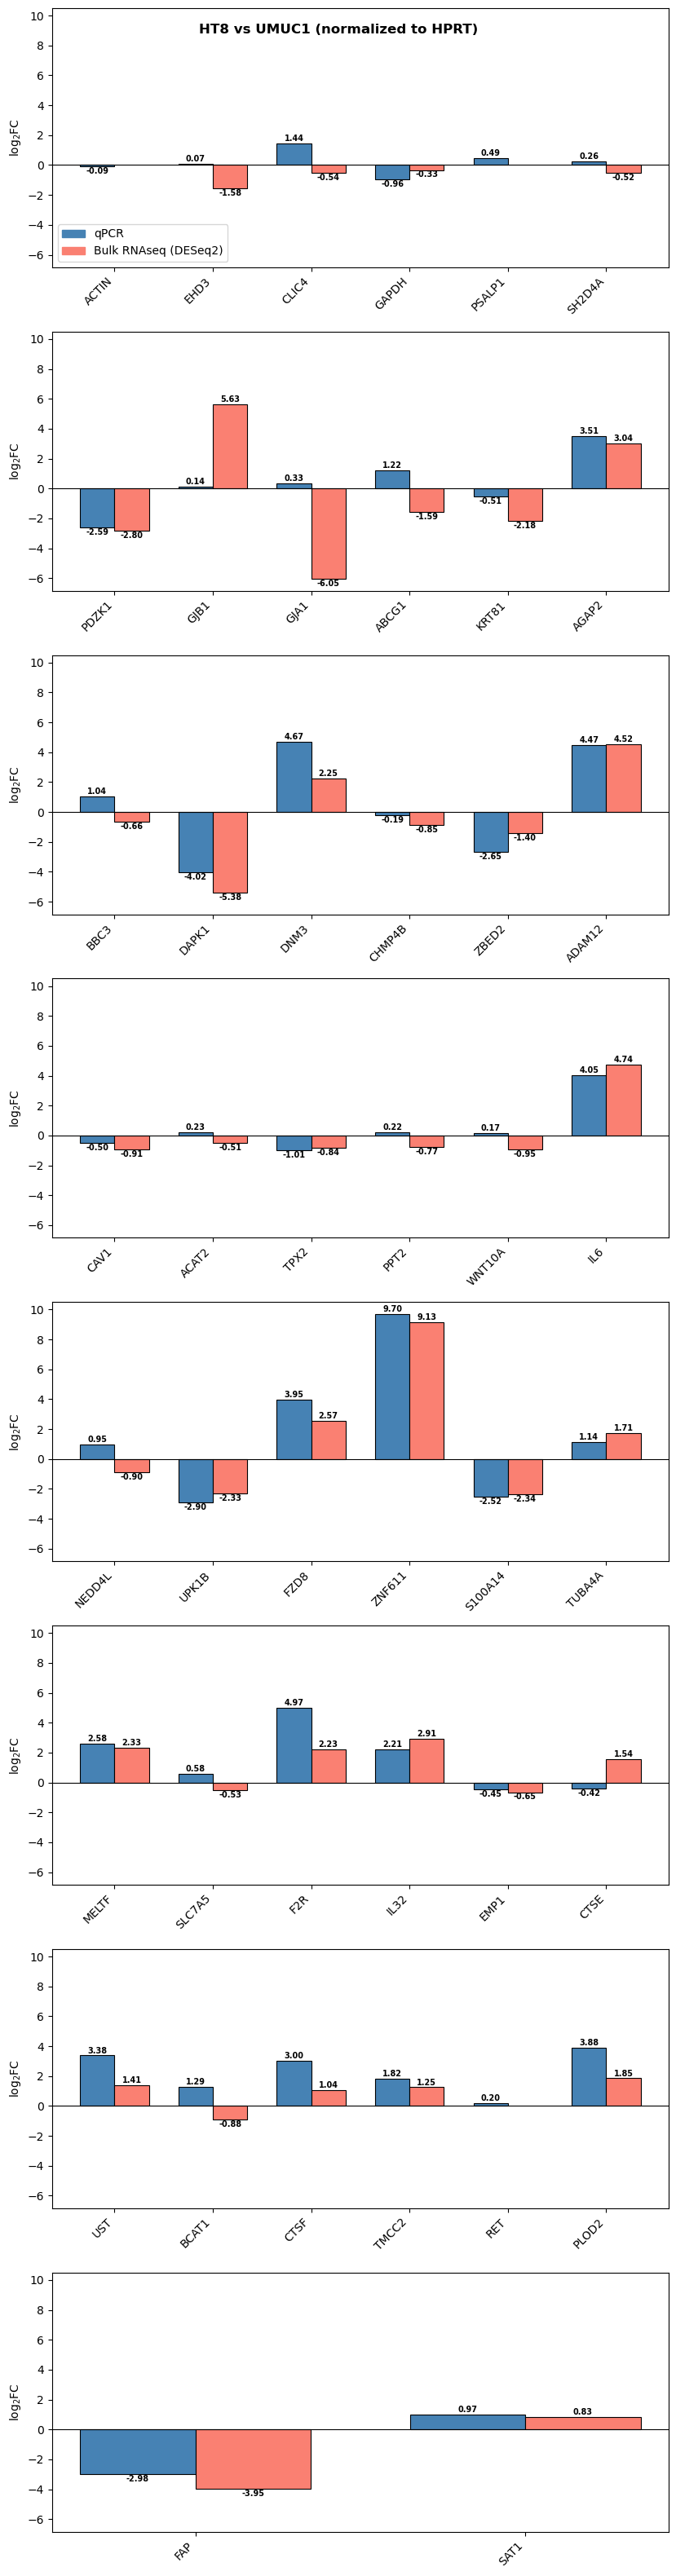

Saved as qpcr_vs_rnaseq_HT8_vs_UMUC1.png


In [46]:
plot_qpcr_vs_rnaseq(
    qpcr_df=qpcr_df,
    rnaseq_df=rnaseq_df,
    hkg="HPRT",
    test_sample="HT8",
    reference_sample="UMUC1"
)